# Feature Extraction and Price Prediction using Machine Learning Project

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Loading Excel file
df = pd.read_excel("feature Processed_Flipdata.xlsx")

# Checking- 
print(df.shape)        # rows and columns
print(df.info())       # data types and nulls
df.head()              # first 5 rows this will show

(541, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB
None


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [12]:
# checking column names

for col in df.columns:
    print(col)

Unnamed: 0
Model
Colour
Memory
RAM
Battery_
Rear Camera
Front Camera
AI Lens
Mobile Height
Processor_
Prize


In [19]:
# Rename some columns 
df.rename(columns={'Battery_':'Battery','Processor_':'Processor','Prize':'Price'}, inplace=True)

In [20]:
# checking column names again

for col in df.columns:
    print(col)

Unnamed: 0
Model
Colour
Memory
RAM
Battery
Rear Camera
Front Camera
AI Lens
Mobile Height
Processor
Price


In [13]:
# Handling missing values
df = df.dropna()  


# Removing duplicates
df = df.drop_duplicates()

# Checking again
print(df.isnull().sum())   # This will confirm there are no missing values
print(df.duplicated().sum())  #  and confirming no duplicates

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64
0


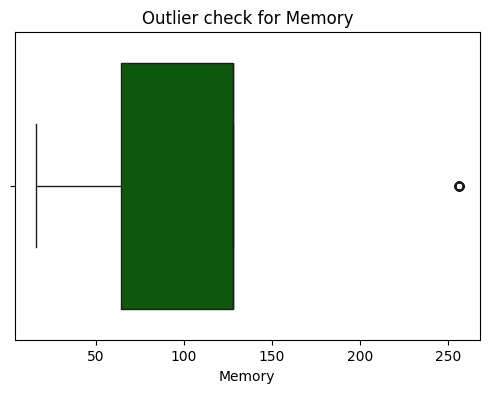

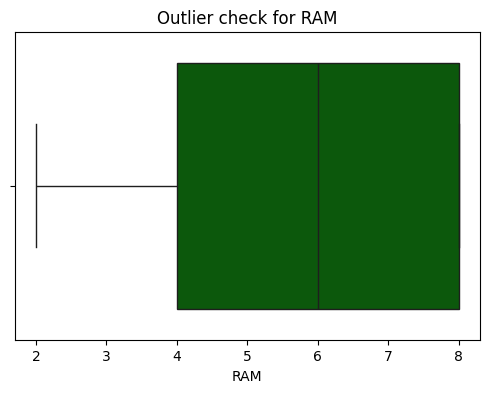

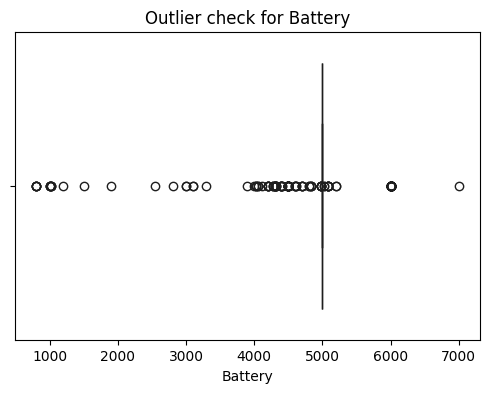

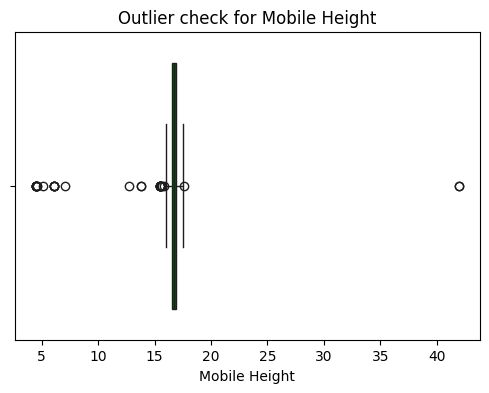

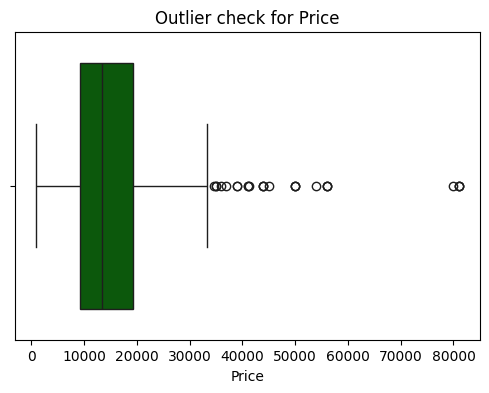

In [69]:
numeric_cols = ['Memory','RAM','Battery','Mobile Height','Price']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color="darkgreen")
    plt.title(f"Outlier check for {col}")
    plt.show()

In [25]:
# Checking Which Columns Are Categorical

# See data types
print(df.dtypes)

Unnamed: 0         int64
Model             object
Colour            object
Memory             int64
RAM                int64
Battery            int64
Rear Camera       object
Front Camera      object
AI Lens            int64
Mobile Height    float64
Processor         object
Price              int64
dtype: object


In [26]:
# Or list only object-type columns (categorical)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['Model', 'Colour', 'Rear Camera', 'Front Camera', 'Processor']


# One-Hot Encoding

In [27]:
# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Check new shape and columns
print(df_encoded.shape)
print(df_encoded.columns.tolist()[:20])  # show first 20 columns

(541, 614)
['Unnamed: 0', 'Memory', 'RAM', 'Battery', 'AI Lens', 'Mobile Height', 'Price', 'Model_APPLE iPhone 12', 'Model_APPLE iPhone 14 Plus', 'Model_Google Pixel 6a', 'Model_Google Pixel 7', 'Model_Google Pixel 7a', 'Model_I Kall Z19Pro', 'Model_I Kall Z19Pro Flash blue', 'Model_IQOO Neo 7 5G', 'Model_Infinix HOT 12 Play', 'Model_Infinix HOT 20 5G', 'Model_Infinix HOT 20 Play', 'Model_Infinix HOT 30i', 'Model_Infinix Hot 11']


In [28]:
# Confirm Encoding

df_encoded.head()

,Unnamed: 0,Memory,RAM,Battery,AI Lens,Mobile Height,Price,Model_APPLE iPhone 12,Model_APPLE iPhone 14 Plus,Model_Google Pixel 6a,...,Processor_Unisoc Spreadtrum SC9863A1,Processor_Unisoc T606,Processor_Unisoc T610,Processor_Unisoc T612,Processor_Unisoc T612 processor,Processor_Unisoc T616,Processor_Unisoc Tiger T612 (12 nm),Processor_Unisoc Tiger T616,Processor_ios,Processor_snapdragon 888
0,0,64,4,6000,1,16.76,7299,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,1,64,4,6000,1,16.76,7299,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,2,128,8,5000,0,16.64,11999,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3,32,2,5000,0,16.56,5649,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,128,8,5000,1,16.76,8999,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# Univariate Analysis

In [30]:
# Summary Statistics for Numeric Columns

# Quick summary of numeric columns (shows mean, min, max, quartiles, etc)
print(df_encoded.describe())

       Unnamed: 0      Memory         RAM      Battery     AI Lens  \
count  541.000000  541.000000  541.000000   541.000000  541.000000   
mean   289.711645  110.550832    5.397412  4871.587800    0.062847   
std    182.359185   60.600694    1.984923   780.148862    0.242911   
min      0.000000   16.000000    2.000000   800.000000    0.000000   
25%    135.000000   64.000000    4.000000  5000.000000    0.000000   
50%    273.000000  128.000000    6.000000  5000.000000    0.000000   
75%    434.000000  128.000000    8.000000  5000.000000    0.000000   
max    642.000000  256.000000    8.000000  7000.000000    1.000000   

       Mobile Height         Price  
count     541.000000    541.000000  
mean       16.431201  16228.375231  
std         2.523553  10793.588322  
min         4.500000    920.000000  
25%        16.510000   9290.000000  
50%        16.710000  13499.000000  
75%        16.940000  19280.000000  
max        41.940000  80999.000000  


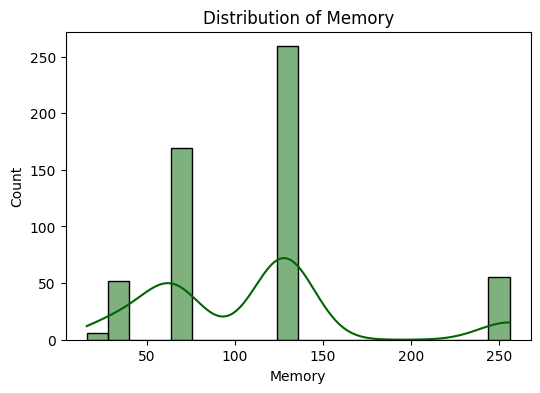

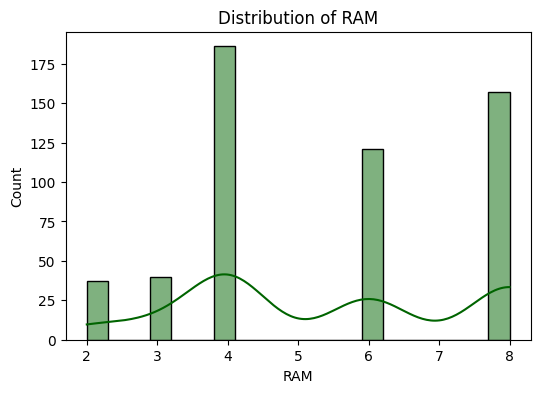

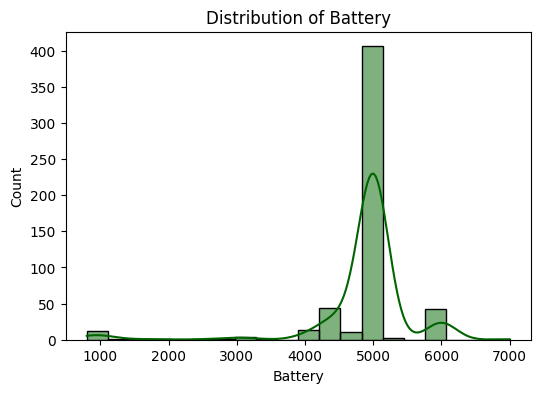

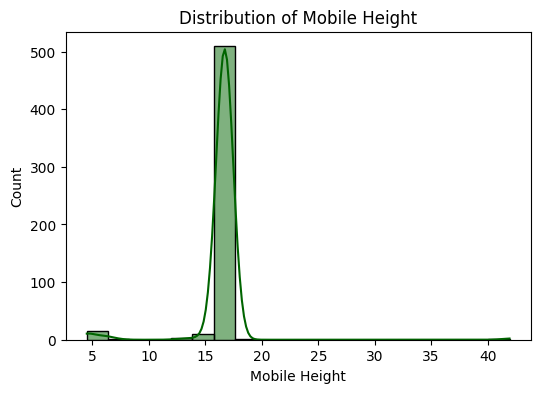

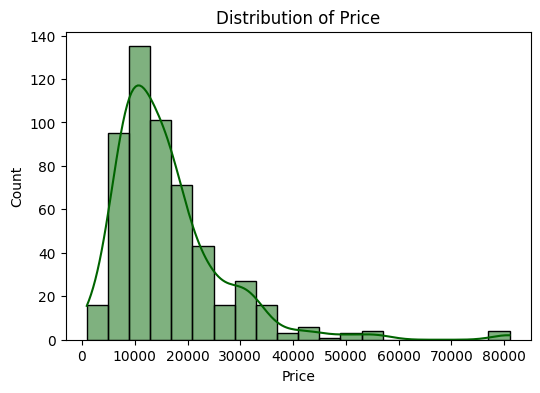

In [70]:
# Distribution Plots for Numeric Columns (how values are spread (((normal, skewed, etc.))).)


numeric_cols = ['Memory','RAM','Battery','Mobile Height','Price']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_encoded[col], kde=True, bins=20, color="darkgreen")
    plt.title(f"Distribution of {col}")
    plt.show()

In [37]:
# Frequency Counts for Categorical Columns (which models, colours, processors appear most often)

categorical_cols = ['Model','Colour','Rear Camera','Front Camera','Processor']

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().head(10))  # top 10 categories


Value counts for Model:
Model
vivo Y16                 9
realme C55               9
SAMSUNG Galaxy A14 5G    9
REDMI Note 12 Pro 5G     9
vivo T1 44W              8
Infinix HOT 30i          8
REDMI 10                 8
SAMSUNG Galaxy F14 5G    8
vivo T2x 5G              8
realme C33 2023          6
Name: count, dtype: int64

Value counts for Colour:
Colour
Yellow            12
Royal Blue         8
Power Black        8
Black              8
Midnight Black     7
Cool Blue          7
Glacier Blue       6
Aqua Blue          6
Force Black        6
Light Green        5
Name: count, dtype: int64

Value counts for Rear Camera:
Rear Camera
50MP     260
13MP      63
64MP      62
8MP       52
48MP      31
108MP     31
0MP       10
12MP      10
200MP      8
2MP        6
Name: count, dtype: int64

Value counts for Front Camera:
Front Camera
16MP    164
5MP     135
8MP     129
13MP     49
32MP     22
0MP      16
50MP      7
12MP      6
60MP      4
2MP       3
Name: count, dtype: int64

Value counts 

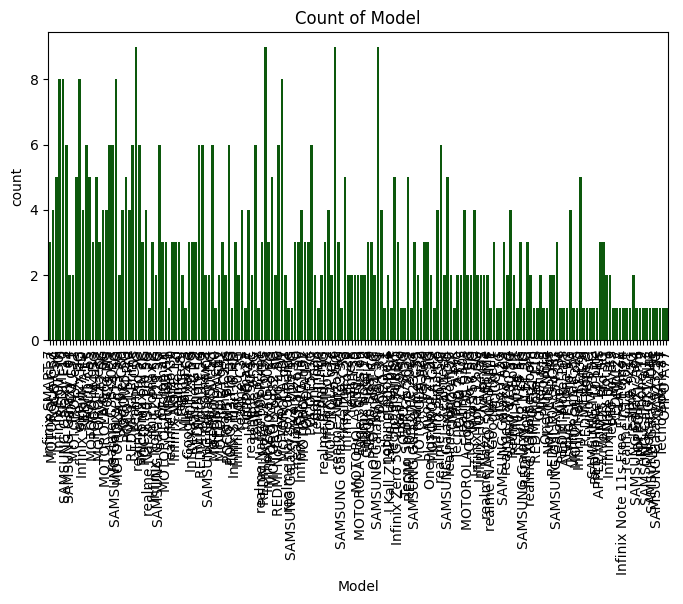

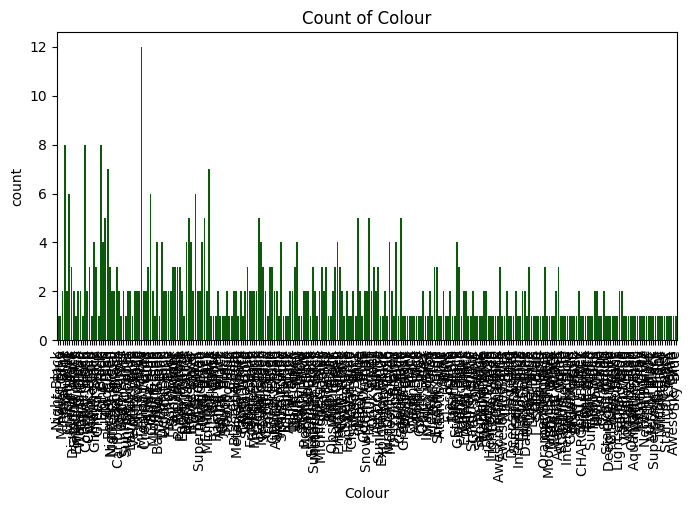

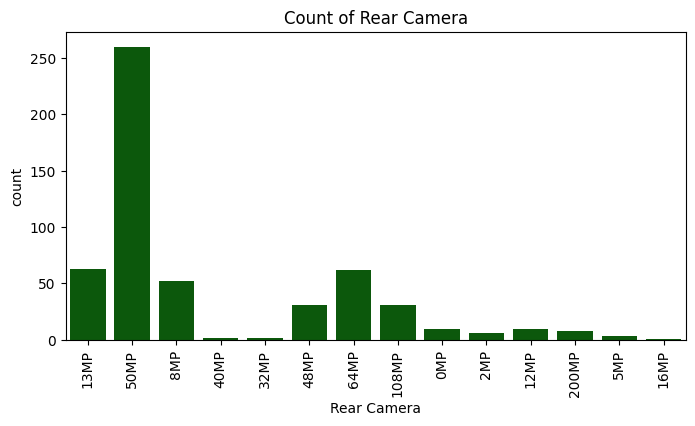

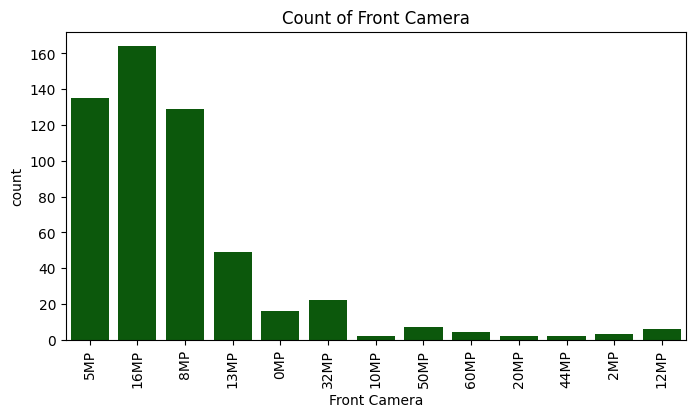

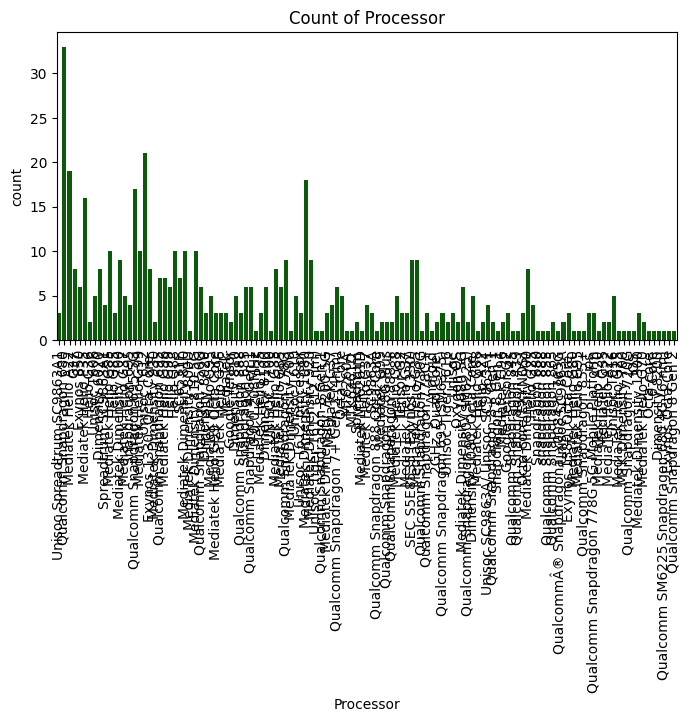

In [71]:
# Bar Plots for Categorical Columns (visual of category distributions)


for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], color="darkgreen")
    plt.title(f"Count of {col}")
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
## There are messy plots happen because of too many categories

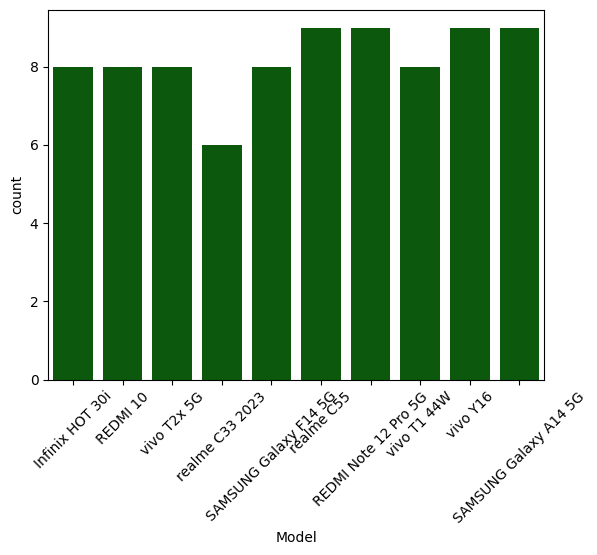

In [72]:
# just to make them cleaner

# Show only top 10 most frequent models
top_models = df['Model'].value_counts().nlargest(10).index
sns.countplot(x=df[df['Model'].isin(top_models)]['Model'], color="darkgreen")
plt.xticks(rotation=45)
plt.show()

## Bivariate Analysis (Feature Extraction)

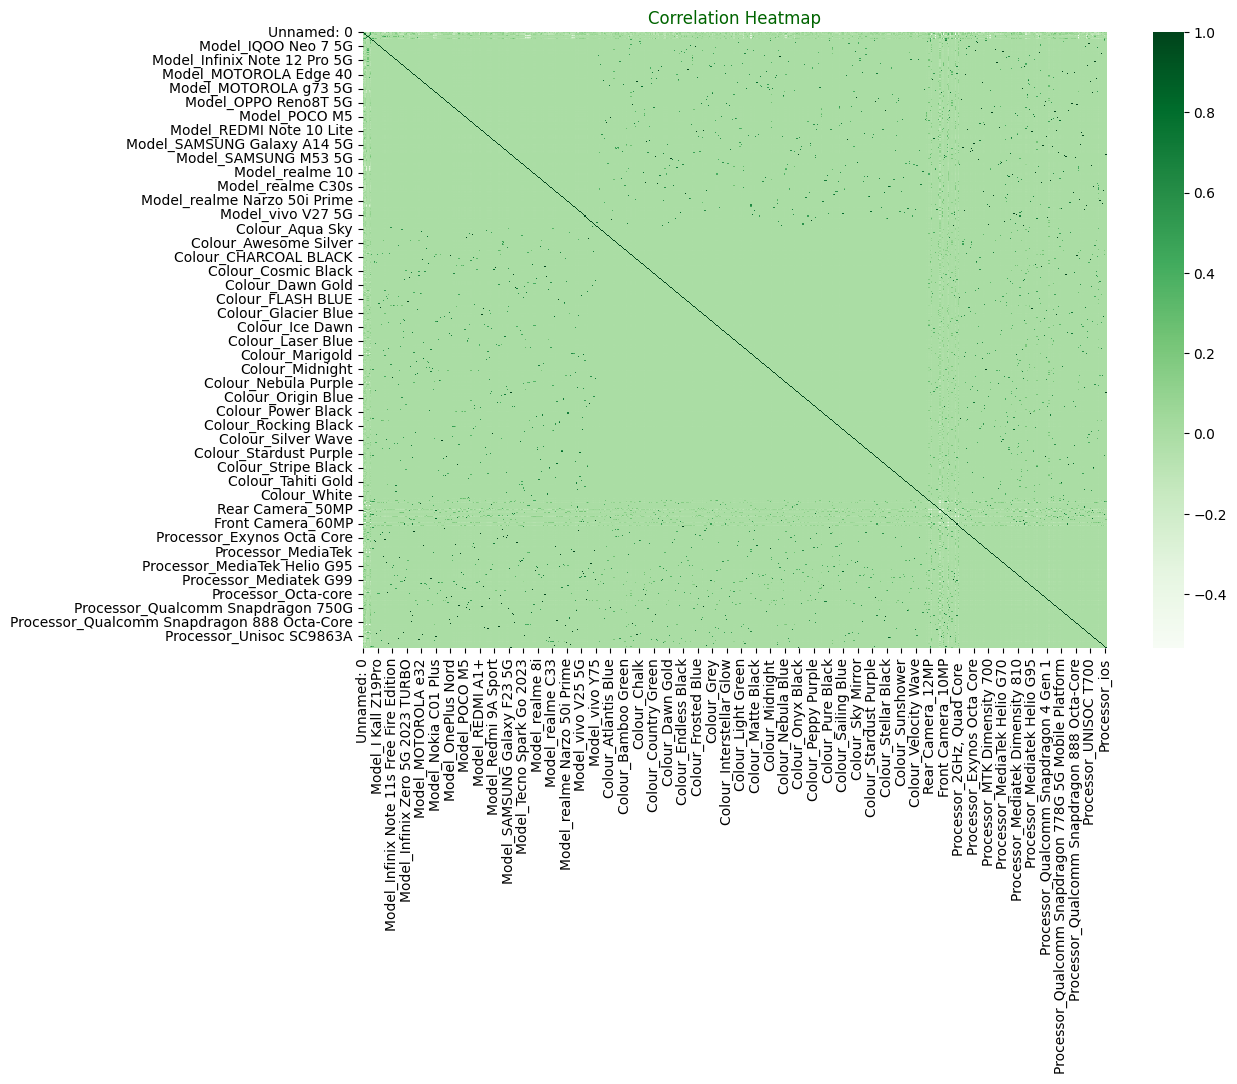

In [45]:
# Correlation Heatmap (Numeric Features vs Price) 
# This shows how strongly each numeric feature relates to Price

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=False, cmap="Greens")  # dark green colormap
plt.title("Correlation Heatmap", color="darkgreen")
plt.show()

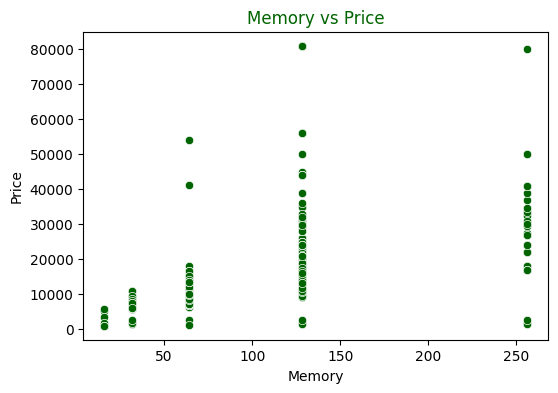

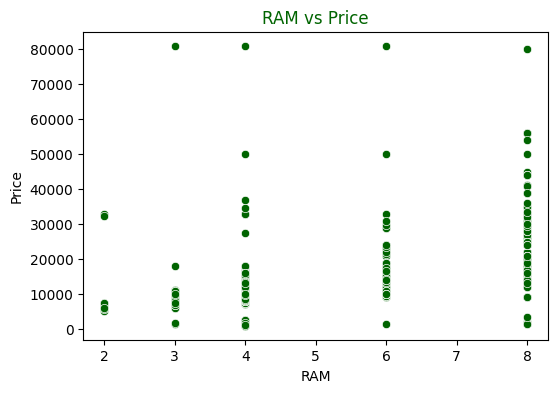

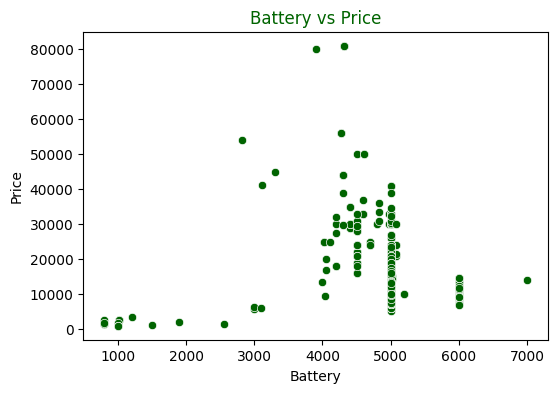

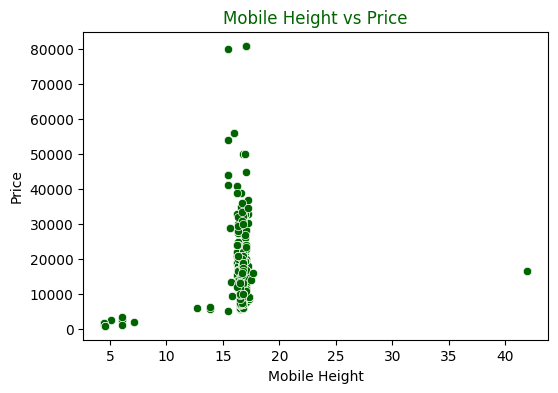

In [46]:
# Scatterplots (Feature vs Price)
# Helps to see if higher RAM, Memory, or Battery capacity increases price


for col in ['Memory','RAM','Battery','Mobile Height']:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df_encoded[col], y=df_encoded['Price'], color="darkgreen")
    plt.title(f"{col} vs Price", color="darkgreen")
    plt.show()

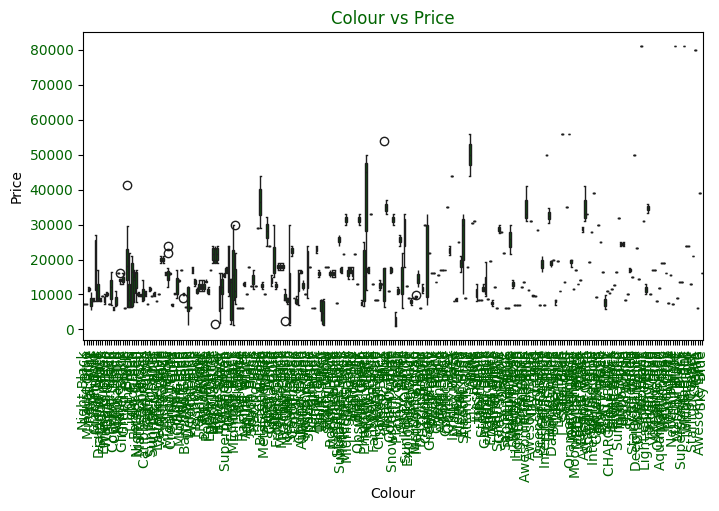

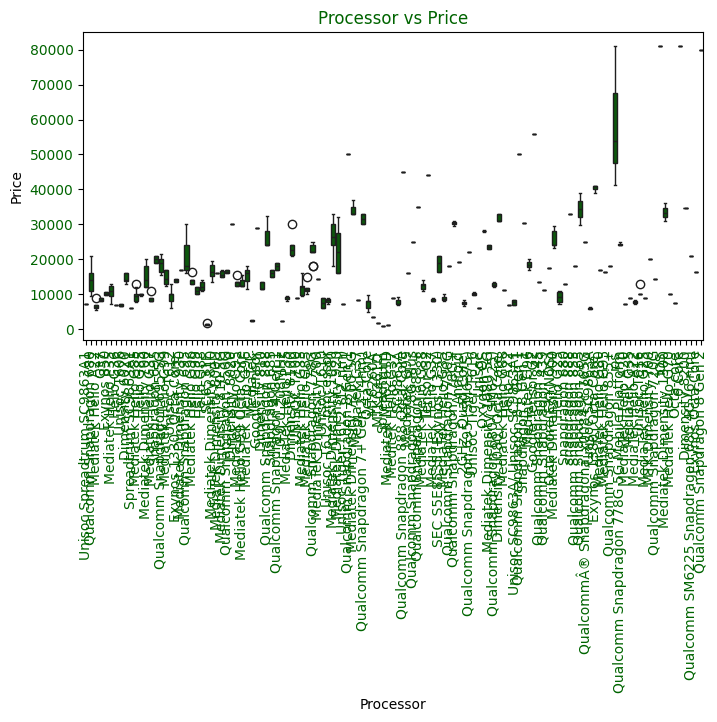

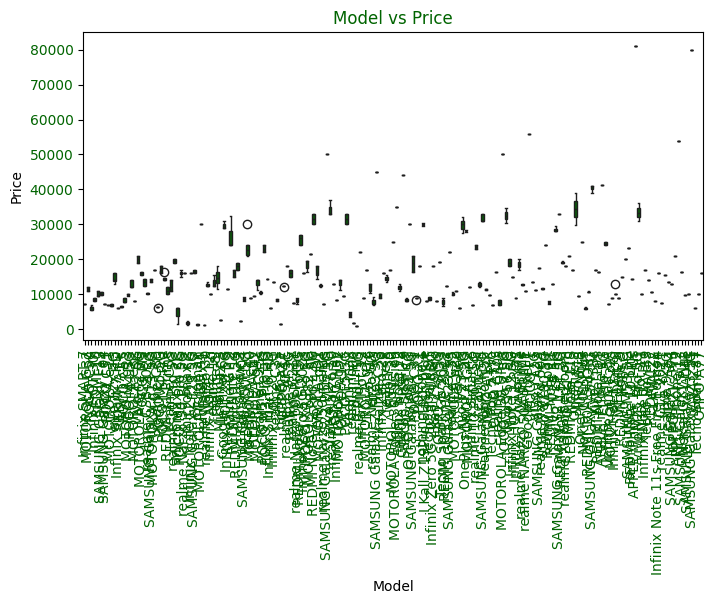

In [47]:
# Boxplots (Categorical Features vs Price)
# Shows how different categories (processor types) affect price

for col in ['Colour','Processor','Model']:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], y=df['Price'], color="darkgreen")
    plt.title(f"{col} vs Price", color="darkgreen")
    plt.xticks(rotation=90, color="darkgreen")
    plt.yticks(color="darkgreen")
    plt.show()

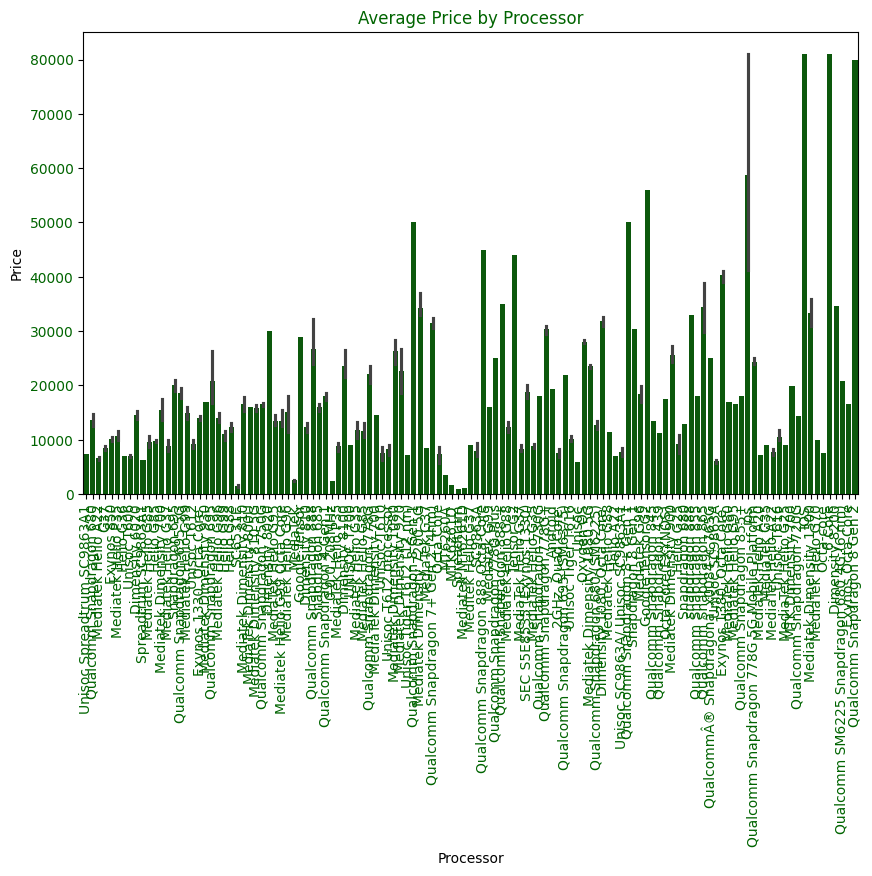

In [48]:
# Boxplots are looking messy so using Aggregated Plots
# shows the average price per processor type instead of messy boxes

plt.figure(figsize=(10,6))
sns.barplot(x="Processor", y="Price", data=df, estimator=np.mean, color="darkgreen")
plt.title("Average Price by Processor", color="darkgreen")
plt.xticks(rotation=90, color="darkgreen")
plt.yticks(color="darkgreen")
plt.show()

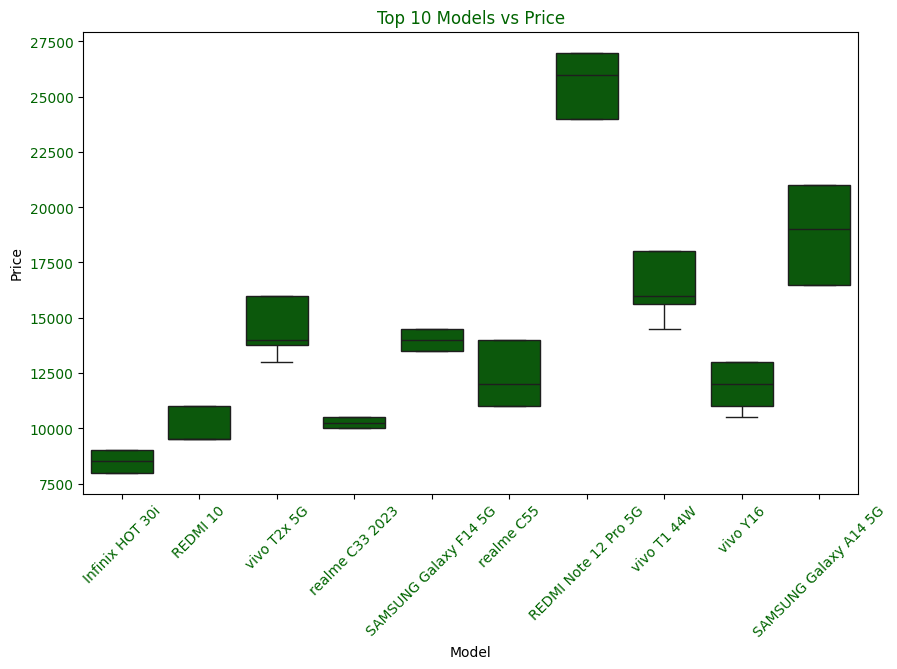

In [49]:
# Show Only Top Categories

top_models = df['Model'].value_counts().nlargest(10).index
plt.figure(figsize=(10,6))
sns.boxplot(x=df[df['Model'].isin(top_models)]['Model'], y=df['Price'], color="darkgreen")
plt.title("Top 10 Models vs Price", color="darkgreen")
plt.xticks(rotation=45, color="darkgreen")
plt.yticks(color="darkgreen")
plt.show()

In [50]:
# Feature Creation


# Example new features
df_encoded['Price_per_GB'] = df_encoded['Price'] / df_encoded['Memory']
df_encoded['RAM_Memory_Ratio'] = df_encoded['RAM'] / df_encoded['Memory']

# Quick check
df_encoded[['Price_per_GB','RAM_Memory_Ratio']].head()

,Price_per_GB,RAM_Memory_Ratio
0,114.046875,0.0625
1,114.046875,0.0625
2,93.742188,0.0625
3,176.531250,0.0625
4,70.304688,0.0625


## Multivariate Analysis

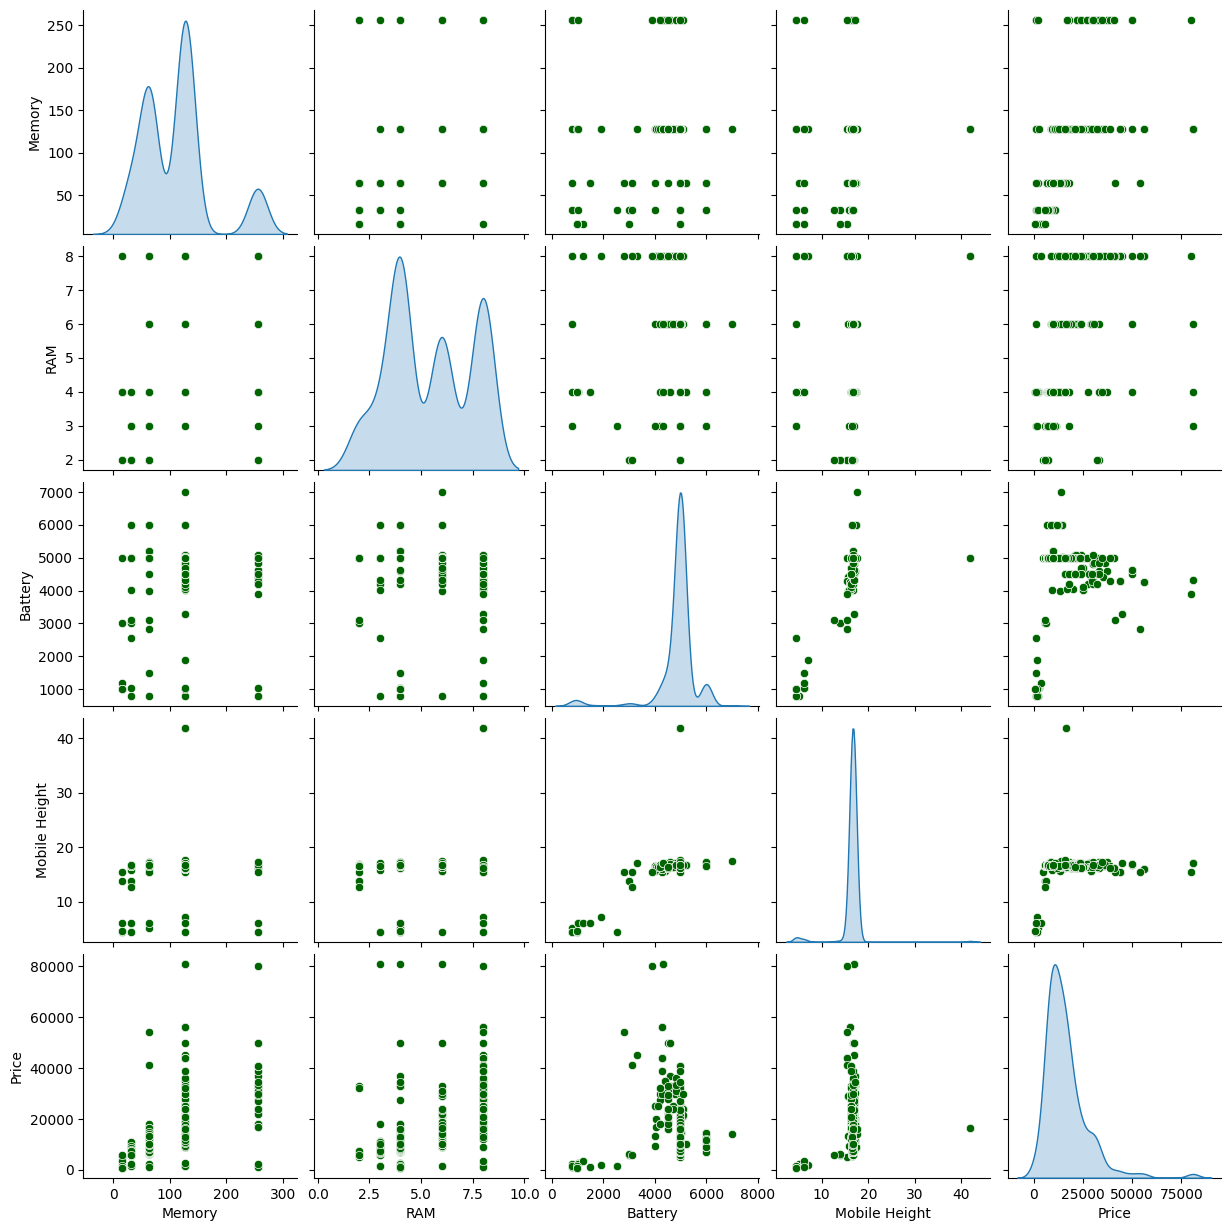

In [51]:
# Pairplot (Multiple Features Together)
# this will show scatterplots between every pair of features, plus distributions on the diagonal


sns.pairplot(df_encoded[['Memory','RAM','Battery','Mobile Height','Price']], 
             diag_kind='kde', plot_kws={'color':'darkgreen'})
plt.show()

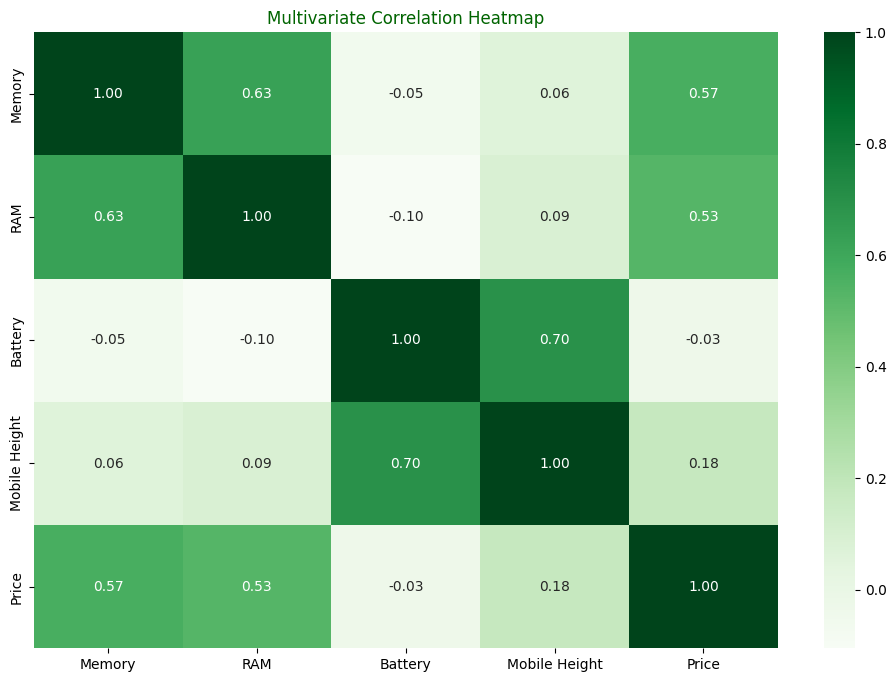

In [52]:
# Advanced Correlation Heatmap
# highlights how features relate to each other and to Price


plt.figure(figsize=(12,8))
corr = df_encoded[['Memory','RAM','Battery','Mobile Height','Price']].corr()
sns.heatmap(corr, annot=True, cmap="Greens", fmt=".2f")
plt.title("Multivariate Correlation Heatmap", color="darkgreen")
plt.show()

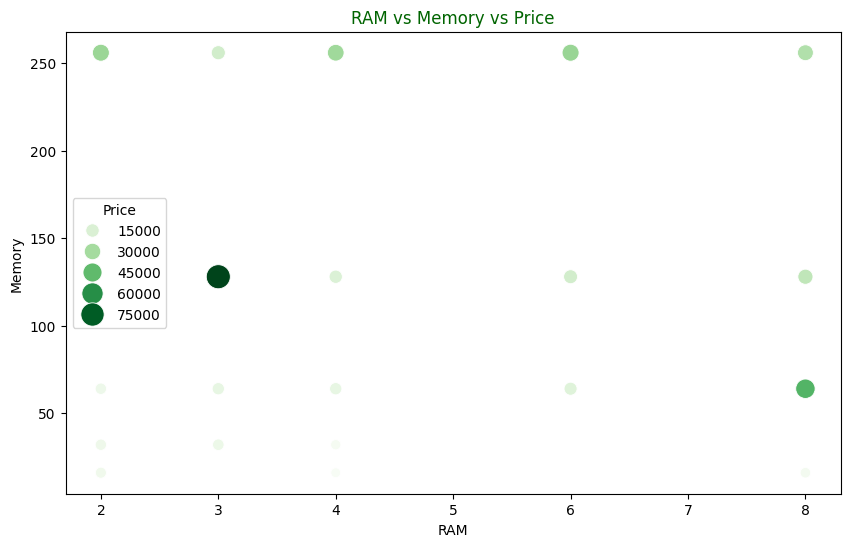

In [53]:
# Grouped Analysis Example
# This shows how RAM + Memory together influence price

# Average price by RAM and Memory together
avg_price = df.groupby(['RAM','Memory'])['Price'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.scatterplot(x='RAM', y='Memory', size='Price', hue='Price', 
                data=avg_price, palette='Greens', sizes=(50,300))
plt.title("RAM vs Memory vs Price", color="darkgreen")
plt.show()

## Feature Scaling

In [54]:
# Split Features and Target

X = df_encoded.drop('Price', axis=1)   # Features
y = df_encoded['Price']                # Target

In [55]:
# Standardization (Z-score scaling)

# Each feature gets mean = 0 and standard deviation = 1.
# Best for algorithms like Linear Regression, Logistic Regression, SVM.

from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
X_standardized = scaler_standard.fit_transform(X)

print("Standardized shape:", X_standardized.shape)

Standardized shape: (541, 615)


In [56]:
# Normalization (Min-Max scaling)


# Rescales values to the range [0,1].
# Best for algorithms like KNN, Neural Networks

from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
X_normalized = scaler_minmax.fit_transform(X)

print("Normalized shape:", X_normalized.shape)


Normalized shape: (541, 615)


# Train/Test Split
# Model Building

In [57]:
# Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_standardized, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (432, 615)
Test set shape: (109, 615)


In [58]:
# Linear Regression Model

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [59]:
# Evaluate Linear Regression

from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression MSE: 36974681.18093147
Linear Regression R2 Score: 0.7317327651979874


In [60]:
# Random Forest Model (for comparison)

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest MSE: 15465514.296037616
Random Forest R2 Score: 0.8877910336890568


# Random Forest is better because- 

# It has a lower Mean Squared Error (MSE) means predictions are closer to actual values
# It has a higher R2 score that explains more variance in the data (88% vs 73%)

In [63]:
# Optimization
# Tuning the model’s hyperparameters to improve accuracy. 

# For Random Forest, important ones include:
# n_estimators = number of trees
# max_depth = maximum depth of each tree
# min_samples_split = minimum samples required to split a node
# min_samples_leaf = minimum samples required at a leaf node

In [64]:
# Grid Search Example

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search with cross-validation
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R2 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best R2 Score: 0.9120010293694386


In [66]:
# Retrain the Random Forest with Best Parameters

In [67]:
optimized_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42
)

optimized_rf.fit(X_train, y_train)
y_pred_opt = optimized_rf.predict(X_test)

print("Optimized RF MSE:", mean_squared_error(y_test, y_pred_opt))
print("Optimized RF R2 Score:", r2_score(y_test, y_pred_opt))

Optimized RF MSE: 16886545.801939104
Optimized RF R2 Score: 0.8774808381585181


In [ ]:
# This output means- 

# Best Parameters (from GridSearchCV):  
# n_estimators=200, max_depth=10, min_samples_split=2, min_samples_leaf=2

# Cross‑validated R2 Score: 0.91 (very strong)
# Test Set Performance (after retraining):
# MSE = 168M
# R2 = 0.877

# The cross‑validation score (0.91) shows the model generalizes well across folds.

# The test set R2 (0.877) is slightly lower than the CV score, which is normal — it means the model is strong but not overfitted.
# Compared to baseline Random Forest (R2 = 0.887), the optimized model is very close. Sometimes optimization improves stability rather than raw accuracy.

# Feature Importance

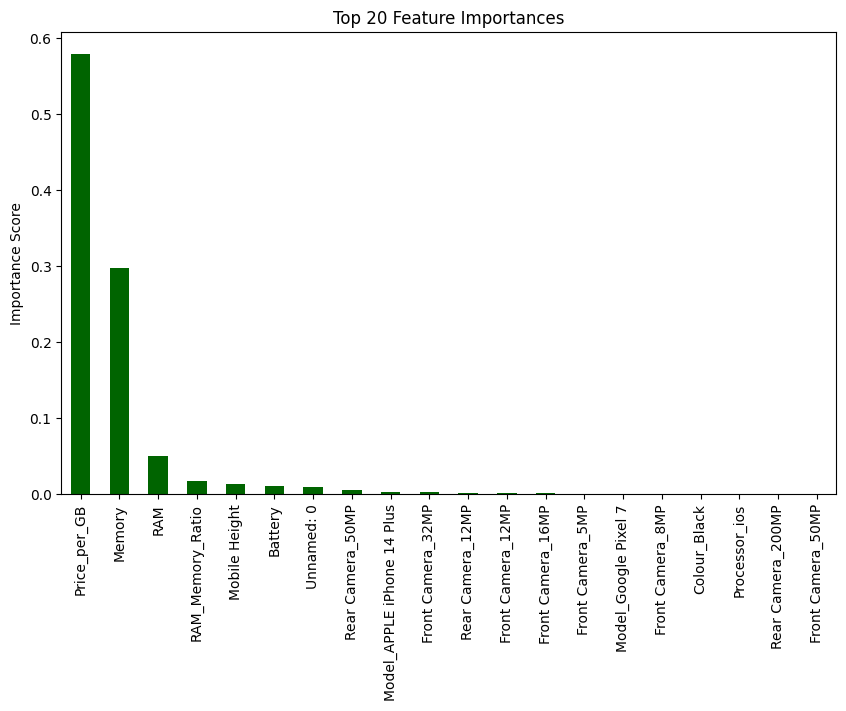

In [68]:
# Extract Feature Importances
# Random Forest gives direct measure of how important each feature is- 

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = optimized_rf.feature_importances_
feature_names = df_encoded.drop('Price', axis=1).columns

# Create a sorted series
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Display top 20 features
plt.figure(figsize=(10,6))
feat_imp.head(20).plot(kind='bar', color='darkgreen')
plt.title("Top 20 Feature Importances")
plt.ylabel("Importance Score")
plt.show()

# Feature importance analysis revealed that variables such as Price per GB, RAM, Memory, and Battery capacity are among the strongest predictors of mobile phone price.

Top drivers = Price_per_GB, Memory, RAM, Battery

Moderate = Mobile_Height, Camera specs

Minor = Colour, Processor type